In [308]:
import glob                                                                                                
import pandas as pd
import geopandas as gp
import seaborn as sns
import matplotlib.pyplot as plt

files = glob.glob("data/scrap-pagebogota-*.csv")                       
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

## 1. Data Overview

The dataset comprises approximately 70,000 residential property listings scraped from Bogotá, each described by 26 features including built area (m²), number of bedrooms, socioeconomic stratum, parking availability, and listing price, among others.

The goal of this notebook is to perform an Exploratory Data Analysis (EDA) to assess data quality, understand feature distributions, and prepare the dataset for feature engineering and modeling. Location-based signals such as Points of Interest (POIs) will also be incorporated in subsequent stages.

In [309]:
df.columns

Index(['id', 'area_m2', 'cuartos', 'estrato', 'tipo', 'parqueaderos', 'banios',
       'piso', 'precio', 'precio_m2', 'precio_admin', 'vendedor',
       'tipo_vendedor', 'tipo_propiedad', 'barrio', 'ciudad', 'lat', 'lon',
       'direccion', 'id_propiedad', 'creado', 'publicado', 'actualizado',
       'antiguedad', 'descripcion', 'url'],
      dtype='object')

## 2. Data Quality

### 2.1 Area (m²) — Bounds Enforcement

According to CAMACOL's Economic Report No. 121 *(Internacionalización de la Vivienda, CAMACOL, 2024)*, the median built area of sold residential units in Bogotá ranges between 60–70 m². Values above 5,000 m² (~200 rows) were identified as outliers and removed, as they likely represent data entry errors or non-residential listings rather than typical housing stock.

> Source: [Informe Económico No. 121 — CAMACOL](https://camacol.co/sites/default/files/descargables/Informe%20Econ%C3%B3mico%20121.pdf)

Additionally, Colombian urban regulation establishes a minimum habitable area of 18 m² for residential units (non-VIS/VIP category). Listings below this threshold do not represent valid residential units and were also removed.

> Source: [Decreto 462 de 2024 — Alcaldía de Bogotá](https://www.alcaldiabogota.gov.co/sisjur/normas/Norma1.jsp?i=139499)

In [310]:
df = df[(df['area_m2'] >= 18) & (df['area_m2'] <= 5000)]

## 3. Feature Selection — Dropping Irrelevant Columns

The following columns carry no predictive signal for price estimation and are removed prior to modeling:

- **`vendedor` / `tipo_vendedor`** — broker identity and type introduce noise and potential data leakage.
- **`tipo`** — single-value column (`venta` across all records), adding no information.
- **`creado`, `publicado`, `actualizado`** — internal timestamps from the data source, not intrinsic properties of the unit.
- **`url`** — listing identifier with no predictive value.

> The `id` column is retained as a join key for merging imputed values back into the dataset.

In [311]:
# The `id` column serves as the join key to merge imputed values back into the original dataset.

df = df.drop(columns=['vendedor', 'tipo_vendedor','id_propiedad','creado','publicado','actualizado','url','tipo'])

## 4. Property Type — Recategorization

The `tipo_propiedad` column contains 11 distinct categories in the raw data (casa, apartamento, apartaestudio, oficina, lote, bodega, etc.). The dataset is restricted to residential units only, excluding commercial and non-standard listings.

Units categorized as `apartaestudio` (studio/loft) are recategorized as `apartamento`, as they share the same structural characteristics. This yields two final classes: **house** and **apartment**.

This decision is consistent with the properties microservice domain model, which enforces a `PropertyType` enum with exactly two values (`house`, `apartment`), ensuring alignment between the training data distribution and the production system's data contract.

In [312]:
df['tipo_propiedad'].unique()

array(['apartamento', 'casa', 'apartaestudio', 'oficina', 'consultorio',
       'local', 'habitacion', 'casa lote', 'lote', 'casa campestre',
       'bodega', 'finca', 'edificio', 'cabaña'], dtype=object)

In [313]:
correcciones = {
    'apartaestudio': 'apartamento',                                                                        
    'casa lote': 'casa',
    'casa campestre': 'casa',                                                                              
    'cabaña': 'casa',
}                                                                                                          
                                                                                                             
df['tipo_propiedad'] = df['tipo_propiedad'].replace(correcciones)
df = df[df['tipo_propiedad'].isin(['apartamento', 'casa'])]

<Axes: xlabel='tipo_propiedad', ylabel='count'>

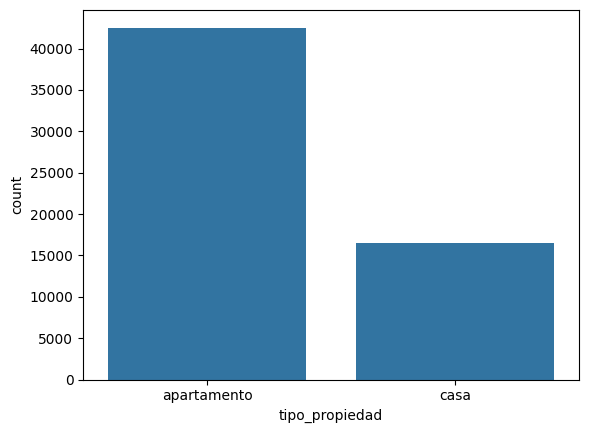

In [314]:
sns.countplot(df, x="tipo_propiedad")

(0.0, 500.0)

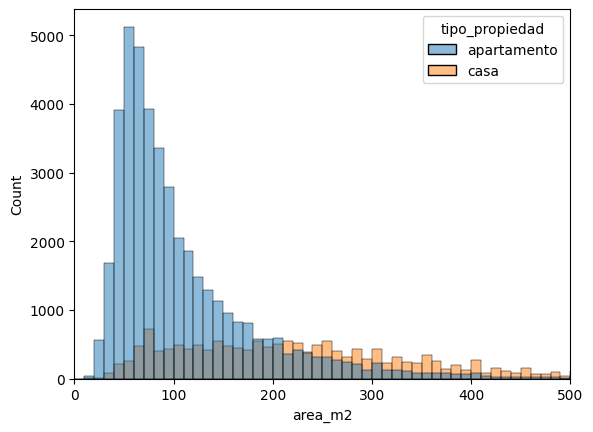

In [315]:
sns.histplot(data=df, x="area_m2", bins=100, binrange=(0, 1000), hue='tipo_propiedad')
plt.xlim(0, 500)

### 4.1 Distribution

The dataset is heavily skewed towards apartment listings, reflecting Bogotá's urban density — a city where multi-family buildings dominate, particularly in consolidated neighborhoods.

Regarding built area, the majority of residential units fall below 100 m², consistent with the CAMACOL benchmark discussed in section 2.1. Apartments concentrate within this range by design, while houses may exceed it due to multi-floor configurations that accumulate total built area across levels.

## 5. Stratum (Estrato) Imputation — Spatial K-Nearest Neighbors

The `estrato` column presents missing or ambiguous values encoded as `"especificar"`. These cannot be reliably imputed using statistical measures alone, as socioeconomic stratum in Bogotá is a spatially defined administrative classification — each city block is assigned a stratum by the local government.

To preserve this spatial semantics, we apply a K-Nearest Neighbors approach using geographic coordinates as the proximity metric. For each listing with a missing stratum, we identify its *k* nearest neighbors among listings with a known stratum and assign the most frequent value (mode) among them.

This is valid because stratum boundaries in Bogotá are spatially contiguous — nearby properties are highly likely to share the same stratum.

In [316]:
df = gp.GeoDataFrame(df, geometry=gp.points_from_xy(df['lat'],df['lon']), crs="EPSG:4326").to_crs(epsg=3116)
impute_stratum = df.loc[df['estrato']=='especificar']

df = df[df['estrato']!='especificar']

geopanads_join = gp.sjoin_nearest(impute_stratum,df,max_distance=500,distance_col="distances")

geopanads_join[['id_left','estrato_left','geometry','id_right','estrato_right','geometry','distances']]

,id_left,estrato_left,geometry,id_right,estrato_right,geometry,distances
13599,b31a7f4a-4b74-416e-afed-bf84b158347c,especificar,POINT (2769096.804 -9155215.315),e7383f54-dc1d-4e21-b037-10eefa40115a,5,POINT (2769096.804 -9155215.315),18.019830
13599,b31a7f4a-4b74-416e-afed-bf84b158347c,especificar,POINT (2769096.804 -9155215.315),acdc9f05-50b6-41d1-8d64-a6dc86a4fef6,5,POINT (2769096.804 -9155215.315),18.019830
14200,4428e784-5d80-4929-ad5a-733c5390d2e5,especificar,POINT (2767085.506 -9154377.244),a5a826eb-0119-4048-9837-2b397aa3bc41,4,POINT (2767085.506 -9154377.244),43.518894
16249,787b75bb-a0c2-4e3e-8b15-3888afc4c2dd,especificar,POINT (2769352.989 -9154379.391),e8c5f4b7-9cbe-4a85-8356-902972b68da9,6,POINT (2769352.989 -9154379.391),9.377915
21053,eb085d23-6cb4-4021-aa68-8791201e14dd,especificar,POINT (2765452.092 -9152743.907),ce4f31de-a610-43ad-82ae-b74656fef07c,3,POINT (2765452.092 -9152743.907),41.150564
30268,bbd8ad95-1c32-416a-829b-72923a2dac6f,especificar,POINT (2766922.35 -9156653.107),58eac099-1130-4997-b965-3f598d5b0a3d,3,POINT (2766922.35 -9156653.107),19.717891
30687,3712b13e-88a7-47cd-9e94-1af4f6edc5a2,especificar,POINT (2768390.695 -9154138.769),f5198ff8-b0ef-4432-89e8-7280d03a73df,5,POINT (2768390.695 -9154138.769),11.828574
35056,07903560-5776-4e65-ada4-fb14243dbfe8,especificar,POINT (2765152.204 -9153940.214),8ce7405c-f830-4d7d-83ed-8c4735e8b894,4,POINT (2765152.204 -9153940.214),60.243684
43012,19ccfcf3-0129-4438-b123-24a868f3303e,especificar,POINT (2764059.685 -9153350.845),0638e47c-90cd-4f85-add6-adafe6b0957b,4,POINT (2764059.685 -9153350.845),0.000000


### 5.1 Geographic Outlier Removal

One listing was found with coordinates pointing to Mexico (`lat=24.05`, `lon=-104.68`), likely a data entry error from the scraping source. When projected to EPSG:3116 (MAGNA-SIRGAS Colombia), this produces an `Infinity` geometry. Since the dataset is restricted to Bogotá, this record is dropped prior to spatial processing.

In [317]:
i = df[~df.geometry.is_valid | df.geometry.is_empty | df.geometry.isna()].index
df = df.drop(i)

### 5.2 Exploratory Spatial Join

Some properties report a distance of 0 meters to their nearest neighbor. This is expected — apartments within the same residential complex share identical coordinates, as geocoding resolves to the building entrance rather than the individual unit. Since all units in a complex belong to the same stratum by definition, a distance of 0 is a valid spatial signal confirming stratum homogeneity at the building level.

However, `sjoin_nearest` does not support a `k` parameter — it only returns multiple results when neighbors are exactly equidistant, limiting its use for majority-vote imputation. To retrieve the top-*k* nearest neighbors, we switch to scikit-learn's `BallTree`, which allows explicit control over *k* and computes distances efficiently over projected metric coordinates.

In [318]:
import numpy as np
from sklearn.neighbors import BallTree

# Get coordinates in meters to fit the tree
 
coords = np.array([(geom.x, geom.y) for geom in df.geometry])
tree = BallTree(coords, leaf_size=5)

# Impute the missing stratum with the 10 Nearest Neighborhood

query_coords = np.array([(geom.x, geom.y) for geom in impute_stratum.geometry])                             
distances, indices = tree.query(query_coords, k=10)

for i, idx in enumerate(indices):                                                                           
    vecinos = df.iloc[idx]                                                                                  
    estrato_imputado = vecinos['estrato'].mode()[0]                                                         
    impute_stratum.iloc[i, impute_stratum.columns.get_loc('estrato')] = estrato_imputado

# Join the dataframes to get the original one with all missing stratum data corrected

df = pd.concat([df, impute_stratum])

## 6. Feature Imputation — Domain-Driven Rules                                                              

Before proceeding to the EDA, remaining missing or implausible values are addressed  through domain-driven imputation rules rather than purely statistical methods.
                                                                                                            
Socioeconomic and physical constraints in Bogotá's housing market allow us to define hard rules grounded in real-world knowledge. For example:
                                                                                                            
- **Bedrooms (`cuartos`)**: units below 35 m² cannot physically accommodate more than one bedroom — all such listings are set to 1 bedroom regardless of the recorded value.

- **Bathrooms (`banios`)**: imputed using the median grouped by `estrato` and `tipo_propiedad`, as bathroom count correlates strongly with both socioeconomic stratum and property type.                                                                                
                                                                                                            
This hybrid approach — domain rules for structural constraints, statistical imputation for the remainder — reduces the risk of introducing bias while keeping the dataset as complete as possible prior to feature engineering.

In [319]:
correcciones = {
    'Sin especificar': pd.NA,
    0: pd.NA
}

for column in ['cuartos','banios','piso','parqueaderos']:
    df[column] = df[column].replace(correcciones)

df.isnull().sum()

id                    0
area_m2               0
cuartos             500
estrato               0
parqueaderos      13334
banios             1405
piso              18806
precio                0
precio_m2             0
precio_admin          0
tipo_propiedad        0
barrio                0
ciudad                0
lat                   0
lon                   0
direccion             9
antiguedad            0
descripcion           0
geometry              0
dtype: int64

### 6.1 Bedrooms (`cuartos`) — Zero Value Treatment                                                         

The `cuartos` column contains records with a value of 0, which is physically impossible for a residential unit — by definition, every dwelling must have at least one habitable room. These zero values likely represent missing data encoded as 0 by the scraping source rather than a true count.
                                                                                                            
Listings with `cuartos = 0` are inspected by area range to determine the most plausible imputation: units are assigned the minimum of 1 bedroom, with further adjustments applied based on the area thresholds defined in section 6.

(0.0, 500.0)

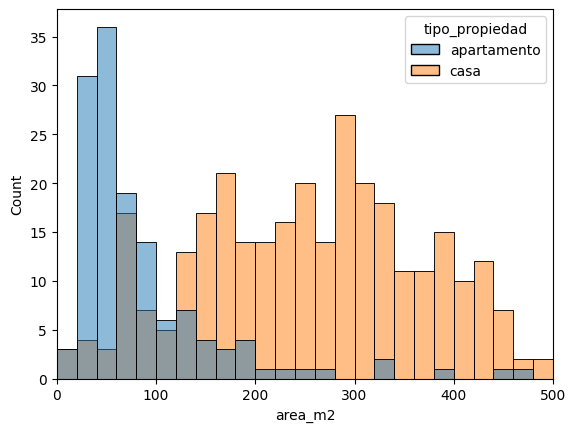

In [320]:
sns.histplot(data=df[df['cuartos'].isnull()], x="area_m2", bins=50, binrange=(0, 1000), hue='tipo_propiedad')
plt.xlim(0, 500)

We can bucketize the area into ranges and impute the number of bedrooms using the median within each bucket. This is preferable to a global median imputation because bedroom count is physically constrained by area — a studio-sized unit and a large house should not receive the same imputed value. By computing the median within each area segment, the imputation reflects the actual distribution of similarly-sized properties in the dataset rather than a single central tendency across all unit sizes.

In [321]:
# Set bins in order to get an aproximation of numer of bathrooms per m2
bins = [0, 35, 60, 90, 120, 200, 5000]

# Calculate the median of each bin
medianas = df.groupby(pd.cut(df['area_m2'], bins=bins), observed=True)['cuartos'].median()

# Replace the missing data according to his correspondent bin
mask = (df['cuartos'].isnull()) | (df['cuartos'] == 0)
df.loc[mask, 'cuartos'] = df.loc[mask, 'area_m2'].apply(lambda x: medianas[pd.cut([x], bins=bins)[0]])

### 6.2 Bathrooms (`banios`) — Median Imputation by Stratum and Property Type                               
                                                                                                              
Missing bathroom values are imputed using the median grouped by `estrato` and `tipo_propiedad`. Unlike bedrooms, bathrooms do not have a strict area-based constraint, but correlate strongly with socioeconomic stratum and property type — a stratum 6 apartment is far more likely to have 2+ bathrooms than a stratum 2 unit of similar size.

In [322]:
df["banios"] = pd.to_numeric(df["banios"], errors="coerce")
df.groupby(["estrato", "tipo_propiedad"]).agg({"banios": "median"})

banios
estrato tipo_propiedad        
0       apartamento        2.0
        casa               3.0
1       apartamento        1.0
        casa               3.0
2       apartamento        1.0
        casa               3.0
3       apartamento        2.0
        casa               3.0
4       apartamento        2.0
        casa               3.0
5       apartamento        3.0
        casa               4.0
6       apartamento        3.0
        casa               5.0

In [323]:
mask = df['banios'].isnull()                                                                                
medianas_banios = df[~mask].groupby(["estrato", "tipo_propiedad"])['banios'].median()
                                                                                                            
df.loc[mask, 'banios'] = df.loc[mask].apply(                                                                
    lambda row: medianas_banios.get((row['estrato'], row['tipo_propiedad'])), axis=1                        
) 

### 6.3 Parking Spots (`parqueaderos`) — Median Imputation by Stratum and Property Type                     
                                                                                                              
Missing parking values are imputed using the median grouped by `estrato` and `tipo_propiedad`. Parking availability in Bogotá correlates strongly with socioeconomic stratum — higher strata developments typically include one or more dedicated parking spots as a standard amenity, while lower strata units rarely do.

In [328]:
df["parqueaderos"] = pd.to_numeric(df["parqueaderos"], errors="coerce")                                     
                                                                                                              
bins = [0, 35, 60, 90, 120, 200, 5000]                                                                      
df['area_bin'] = pd.cut(df['area_m2'], bins=bins)
                                                                                                            
mask = df['parqueaderos'].isnull()                                                                          
medianas_parqueaderos = df[~mask].groupby(
    ["estrato", "tipo_propiedad", "area_bin"], observed=True                                                
)['parqueaderos'].median()                                                                                  

df.loc[mask, 'parqueaderos'] = df.loc[mask].apply(                                                          
    lambda row: medianas_parqueaderos.get((row['estrato'], row['tipo_propiedad'], row['area_bin'])), axis=1
)                                                                                                           

df = df.drop(columns=['area_bin'])

### 6.4 Floor (`piso`) — Semantic Split by Property Type                                                    
                                                                                                              
The `piso` column encodes two semantically different concepts depending on the property type:
                                                                                                            
- **Houses (`casa`)**: `piso` represents the total number of floors in the unit — a structural feature that correlates with total built area and capacity.

- **Apartments (`apartamento`)**: `piso` represents the floor level within a tower — a locational feature that correlates with price, as higher floors typically command a premium in Bogotá's market.                                                                               
                                                                                                            
Treating both under a single column would introduce noise by conflating two distinct signals. The column is therefore split into `num_pisos` (houses only) and `piso_torre` (apartments only), with NaN assigned where the concept does not apply.

(0.0, 10.0)

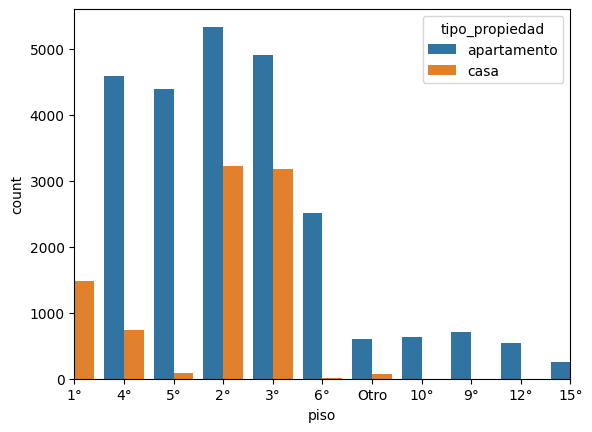

In [331]:
sns.countplot(df, x="piso", hue="tipo_propiedad")
plt.xlim(0, 10)

In [327]:
df.isnull().sum()

id                    0
area_m2               0
cuartos               0
estrato               0
parqueaderos          0
banios                0
piso              18806
precio                0
precio_m2             0
precio_admin          0
tipo_propiedad        0
barrio                0
ciudad                0
lat                   0
lon                   0
direccion             9
antiguedad            0
descripcion           0
geometry              0
dtype: int64

In [326]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

ValueError: could not convert string to float: 'db966c1c-b210-4e9d-a92a-f2a2ba5a4e55'

<Figure size 800x600 with 0 Axes>